In [1]:
# ensure we have qiskit and numpy properly installed
from qiskit import __version__
import numpy as np

print(f'Qiskit version: {__version__}')
print(f'Numpy version: {np.__version__}')

Qiskit version: 2.4.1
Numpy version: 2.2.6


In [2]:
ket1 = np.array([[1], [0]])
ket0 = np.array([[0], [1]])

print(ket0 / 2 + ket1 / 2)

[[0.5]
 [0.5]]


In [3]:
M1 = np.array([[1, 1], [0, 0]])
M2 = np.array([[1, 0], [0, 1]])
M = M1 / 2 + M2 / 2
print(M)

[[1.  0.5]
 [0.  0.5]]


In [4]:
from qiskit.visualization import array_to_latex

# multiplying any probability vector by M1 always yields ket-0
display(array_to_latex(np.matmul(M1, ket1)))
display(array_to_latex(np.matmul(M1, ket0)))
display(array_to_latex(np.matmul(M1, M2)))
display(array_to_latex(np.matmul(M, M)))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [5]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])

# different options for displaying quantum state vectors
display(u.draw("text"))
display(u.draw("latex"))
print(u.draw("latex_source"))

# pretty latext printing of quantum state vectors
display(u.draw("latex"))
display(v.draw("latex"))

# if euclidean norm have values of 1, then the state vector is valid
display(u.is_valid())
display(w.is_valid())

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

\frac{\sqrt{2}}{2} |0\rangle+\frac{\sqrt{2}}{2} |1\rangle


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

True

False

In [6]:
display(v.draw("latex"))
display(w.draw("latex"))

outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))

try:
    outcome, state = w.measure() # should throw err here, as w is not a valid state vector
except ValueError as e:
    print(f"Error: {e}")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Measured: 1
Post-measurement state:


<IPython.core.display.Latex object>

Error: Probabilities do not sum to 1. See Notes section of docstring for more information.


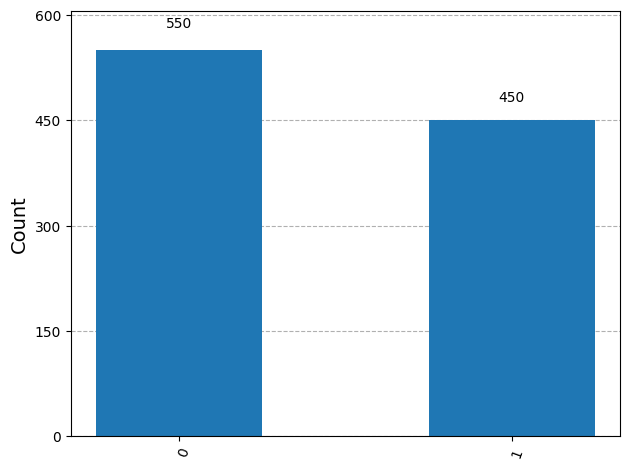

In [7]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

In [8]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(T.draw("latex"))

ket0 = Statevector([1, 0])
ket1 = Statevector([0, 1])

ket0 = ket0.evolve(H)
display(ket0.draw("latex")) # should be plus state

ket1 = ket1.evolve(H)
display(ket1.draw("latex")) # should be minus state



<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

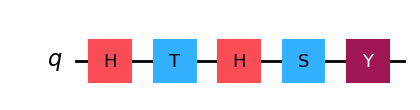

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [ ]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)
circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))
display(Operator.from_circuit(circuit).draw("latex"))

ket1 = Statevector([0, 1])
circuit2 = QuantumCircuit(1)
circuit2.h(0)
v = ket1.evolve(circuit2)
display(v.draw("latex")) # should be minus state

v = ket0.evolve(circuit)
display(v.draw("latex"))

<IPython.core.display.Latex object>

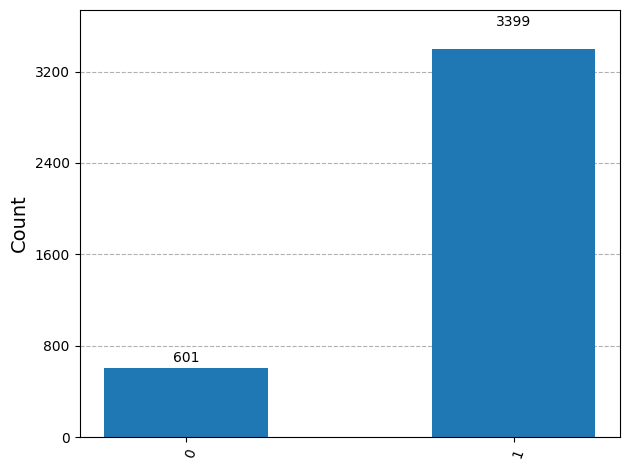

In [17]:
ket0 = Statevector([1, 0])
v = ket0.evolve(circuit)
display(v.draw("latex"))

statistics = v.sample_counts(4000)
display(plot_histogram(statistics))